In [15]:
#-----------------------------------------------------
#Task 1: Data Loading & Inspection
#-----------------------------------------------------

# Import required libraries
import pandas as pd
import numpy as np

# Load the Spotify dataset into DataFrame
df = pd.read_csv("SpotifY_DataSet1.csv")

# Display first 5 rows of the dataset
print("First 5 Rows:")
print(df.head())

# Display dataset structure and data types
print("\nDataset Information:")
print(df.info())

# Display statistical summary of numerical columns
print("\nStatistical Description:")
print(df.describe())

# Check for missing values in each column
print("\nMissing Values:")
print(df.isnull().sum())


First 5 Rows:
   track_no                track_id                     artists  \
0         1  6KwkVtXm8OUp2XffN5k7lY            Hillsong Worship   
1         2  2dp5I5MJ8bQQHDoFaNRFtX                Internal Rot   
2         3  5avw06usmFkFrPjX8NxC40  Zhoobin Askarieh;Ali Sasha   
3         4  75hT0hvlESnDJstem0JgyR                 Bryan Adams   
4         5                     NaN                  Nogizaka46   

                        album_name             track_name  popularity  \
0                    No Other Name          No Other Name        50.0   
1                   Grieving Birth         Failed Organum        11.0   
2             Noise A Noise 20.4-1  Save the Trees, Pt. 1         0.0   
3  All I Want For Christmas Is You        Merry Christmas         0.0   
4                            TypeD                    NaN        57.0   

  explicit  danceability  energy  key  ...  mode  speechiness  acousticness  \
0    False         0.369   0.598  7.0  ...   1.0       0.0304    

In [16]:
#-----------------------------------------------------------------
#TASK-2: DATA CLEANING
#-----------------------------------------------------------------


# Import required libraries
import pandas as pd
import numpy as np

# Load the Spotify dataset
df = pd.read_csv("SpotifY_DataSet1.csv")

# Display missing values before dropping
print("Missing Values Before Dropping:")
print(df.isnull().sum())

# Drop duplicate records
df = df.drop_duplicates()

# Drop rows that have all values missing
df_drop = df.dropna()

# Display missing values after dropping
print("\nMissing Values After Dropping:")
print(df_drop.isnull().sum())
# Fill missing numeric values with column mean
for col in df.select_dtypes(include=["float64", "int64"]).columns:
    df[col] = df[col].fillna(df[col].mean())

# Fill missing categorical values with 'Unknown'
for col in df.select_dtypes(include=["object"]).columns:
    df[col] = df[col].fillna("Unknown")

# Display missing values after filling
print("Missing Values After Filling:")
print(df.isnull().sum())

# Display cleaned dataset
print("\nCleaned Spotify Dataset (First 5 Rows):")
print(df.head())


Missing Values Before Dropping:
track_no             0
track_id             6
artists              4
album_name          15
track_name          20
popularity           5
explicit            10
danceability         6
energy               4
key                  7
loudness             5
mode                 4
speechiness          3
acousticness         4
instrumentalness     5
liveness            10
valence              6
tempo                3
time_signature      10
track_genre          7
duration_min_sec     5
dtype: int64

Missing Values After Dropping:
track_no            0
track_id            0
artists             0
album_name          0
track_name          0
popularity          0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0


In [17]:
# ---------------------------------------------------------
# TASK 3: DATA WRANGLING
# ---------------------------------------------------------

# Import required libraries
import pandas as pd
import numpy as np

# Load the Spotify dataset
df = pd.read_csv("SpotifY_DataSet1.csv")

# ------------------ CHECK DATA TYPES ------------------
print("Data Types Before Conversion:")
print(df.dtypes)

# ------------------ SAFE DATA TYPE CONVERSION ------------------
# Handle Unknown + NaN + string values safely before int conversion
if "explicit" in df.columns:
    df["explicit"] = df["explicit"].replace("Unknown", np.nan)
    df["explicit"] = pd.to_numeric(df["explicit"], errors="coerce")
    df["explicit"] = df["explicit"].fillna(0).astype(int)

print("\nData Types After Conversion:")
print(df.dtypes)

# ------------------ DERIVED COLUMN 1 ------------------
# Convert duration from milliseconds to minutes
if "duration_ms" in df.columns:
    df["duration_min"] = df["duration_ms"] / 60000

# ------------------ DERIVED COLUMN 2 ------------------
# Create popularity level column
if "popularity" in df.columns:
    df["popularity_level"] = np.where(df["popularity"] > 60, "High", "Low")

# ------------------ NORMALIZATION ------------------
# Apply Min-Max normalization on 'energy' column
if "energy" in df.columns:
    df["energy_norm"] = (df["energy"] - df["energy"].min()) / \
                        (df["energy"].max() - df["energy"].min())

# ------------------ ENCODING (LABEL ENCODING) ------------------
# Encode popularity level column
if "popularity_level" in df.columns:
    df["popularity_level_encoded"] = df["popularity_level"].map(
        {"Low": 0, "High": 1}
    )

# Encode first categorical column automatically
cat_cols = df.select_dtypes(include="object").columns
if len(cat_cols) > 0:
    first_cat = cat_cols[0]
    df[first_cat + "_encoded"] = df[first_cat].astype("category").cat.codes

# ------------------ FINAL OUTPUT ------------------
print("\nFinal Dataset After Data Wrangling:")
print(df.head())


Data Types Before Conversion:
track_no              int64
track_id             object
artists              object
album_name           object
track_name           object
popularity          float64
explicit             object
danceability        float64
energy              float64
key                 float64
loudness            float64
mode                float64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature      float64
track_genre          object
duration_min_sec     object
dtype: object

Data Types After Conversion:
track_no              int64
track_id             object
artists              object
album_name           object
track_name           object
popularity          float64
explicit              int64
danceability        float64
energy              float64
key                 float64
loudness            float64
mode                float64
sp

In [19]:
# ---------------------------------------------------------
# TASK 4: FILTERING & INDEXING 
# ---------------------------------------------------------

# Import required libraries
import pandas as pd
import numpy as np

# ------------------ LOAD DATASET ------------------
# Load the Spotify dataset into a DataFrame
df = pd.read_csv("SpotifY_DataSet1.csv")

# Display first 5 records of the dataset
print("Original Dataset:")
print(df.head())


# ------------------ FILTERING USING LOGICAL CONDITIONS ------------------

# a) Filter songs with high popularity (> 80)
if "popularity" in df.columns:
    high_popularity = df[df["popularity"] > 80]
    print("\nSongs with High Popularity (>80):")
    print(high_popularity.head())

# b) Filter only explicit songs
if "explicit" in df.columns:
    explicit_songs = df[df["explicit"] == 1]
    print("\nExplicit Songs:")
    print(explicit_songs.head())

# c) Filter songs with high energy AND high danceability
if "energy" in df.columns and "danceability" in df.columns:
    high_energy_dance = df[(df["energy"] > 0.7) & (df["danceability"] > 0.7)]
    print("\nHigh Energy & High Danceability Songs:")
    print(high_energy_dance.head())

# d) Filter songs with low loudness OR low tempo
if "loudness" in df.columns and "tempo" in df.columns:
    low_loud_tempo = df[(df["loudness"] < -10) | (df["tempo"] < 90)]
    print("\nLow Loudness OR Low Tempo Songs:")
    print(low_loud_tempo.head())


# ------------------ INDEXING OPERATIONS ------------------

# a) Row indexing using iloc (first 10 rows)
print("\nFirst 10 Rows Using iloc:")
print(df.iloc[0:10])

# b) Column indexing using iloc (first 5 columns)
print("\nFirst 5 Columns Using iloc:")
print(df.iloc[:, 0:5].head())

# c) Access specific row and column value (5th row, 3rd column)
print("\nValue at 5th Row and 3rd Column:")
print(df.iloc[4, 2])

# d) Label-based indexing using loc
print("\nFirst 5 Rows Using loc:")
print(df.loc[0:4])


# ------------------ SETTING MEANINGFUL INDEX ------------------

# Set track name as index (if available)
if "track_name" in df.columns:
    df.set_index("track_name", inplace=True)
    print("\nDataset After Setting Track Name as Index:")
    print(df.head())

# ------------------ RESET INDEX ------------------

# Reset the index back to default
df.reset_index(inplace=True)
print("\nDataset After Resetting Index:")
print(df.head())


# ------------------ FINAL RESULT ------------------
print("\nTASK–4 Filtering & Indexing Completed Successfully!")


Original Dataset:
   track_no                track_id                     artists  \
0         1  6KwkVtXm8OUp2XffN5k7lY            Hillsong Worship   
1         2  2dp5I5MJ8bQQHDoFaNRFtX                Internal Rot   
2         3  5avw06usmFkFrPjX8NxC40  Zhoobin Askarieh;Ali Sasha   
3         4  75hT0hvlESnDJstem0JgyR                 Bryan Adams   
4         5                     NaN                  Nogizaka46   

                        album_name             track_name  popularity  \
0                    No Other Name          No Other Name        50.0   
1                   Grieving Birth         Failed Organum        11.0   
2             Noise A Noise 20.4-1  Save the Trees, Pt. 1         0.0   
3  All I Want For Christmas Is You        Merry Christmas         0.0   
4                            TypeD                    NaN        57.0   

  explicit  danceability  energy  key  ...  mode  speechiness  acousticness  \
0    False         0.369   0.598  7.0  ...   1.0       0.0304

In [8]:
# --------- DISPLAY ALL COLUMN NAMES ----------
# This helps to verify available columns in the dataset
print("Columns in Dataset:")
print(df.columns)


# --------- GROUPING USING A VALID COLUMN ----------
# We safely choose a categorical column that exists
# Example: 'playlist_genre' or 'track_genre' is commonly present in Spotify datasets

group_column = df.select_dtypes(include=["object"]).columns[0]   # first categorical column
numeric_column = df.select_dtypes(include=["int64", "float64"]).columns[0]  # first numeric column

# Group the data using the selected columns
grouped_data = df.groupby(group_column)[numeric_column].mean()

# Display grouped result
print("\nGrouped Data (Mean Calculation):")
print(grouped_data)


# --------- APPLY MULTIPLE AGGREGATION FUNCTIONS ----------
# Applying sum, mean, count, min, median, std on numeric columns
aggregation_result = df.select_dtypes(include=["int64", "float64"]).agg(
    ["sum", "mean", "count", "min", "median", "std"]
)

# Display aggregation table
print("\nAggregation Results:")
print(aggregation_result)


Columns in Dataset:
Index(['track_id', 'artists', 'album_name', 'track_name', 'popularity',
       'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode',
       'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre', 'duration_min_sec',
       'popularity_level'],
      dtype='object')

Grouped Data (Mean Calculation):
track_id
00B7SBwrjbycLMOgAmeIU8    66.0
00GVRTIWMjYwwHEjTLclgf     8.0
00Y9r5SfbDdEjJhNg7laQr    62.0
01LigwR8Dn9cPqCIGIBqwv    31.0
01ZAjuOp09OWWEoNBTmJ8R    18.0
                          ... 
7vk7u7kaqw5A6BtkfoxQf3    46.0
7wiULYwv85WeChygucbpTF    46.0
7z60LyZVJJXrE6YPJ39ioD    18.0
7zRmGvtSy36Jr19U5OInJT    54.0
Unknown                   52.0
Name: popularity, Length: 493, dtype: float64

Aggregation Results:
          popularity    explicit  danceability      energy          key  \
sum     16920.202020   47.000000    281.795547  323.344395  2656.186613   
mean       33.840404    0.094000  

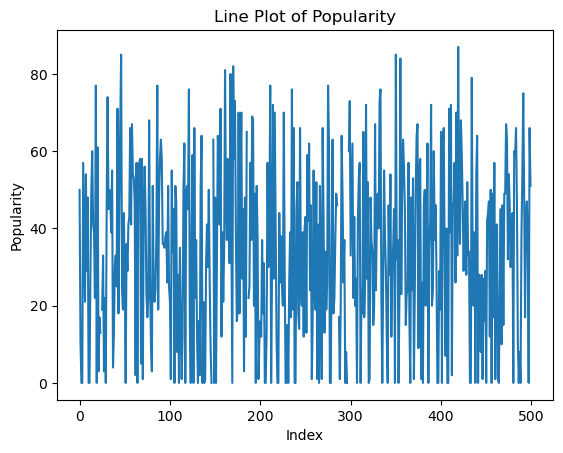

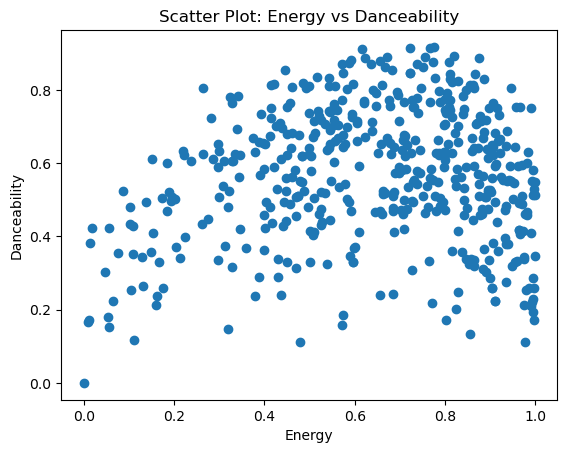

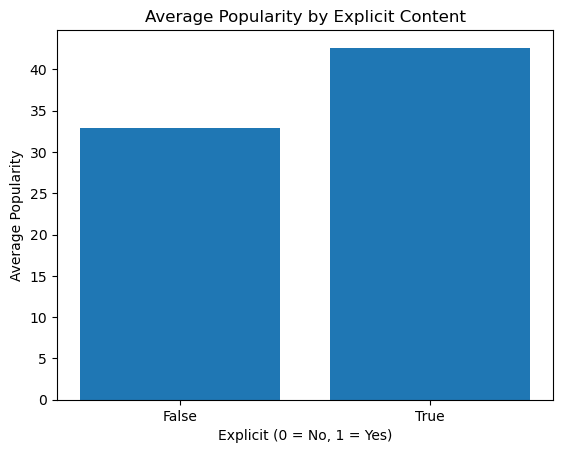

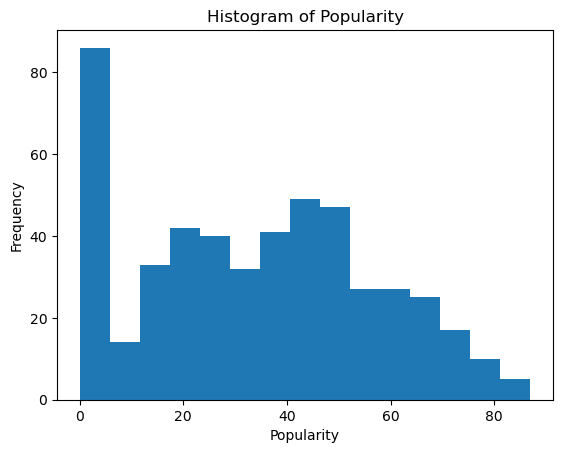

In [21]:
# ---------------------------------------------------------
# TASK 6: VISUALIZATION USING MATPLOTLIB 
# ---------------------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt

# Load the Spotify dataset
df = pd.read_csv("SpotifY_DataSet1.csv")

# ------------------ 1. LINE PLOT ------------------
# Line Plot: Popularity over song index
plt.figure()
plt.plot(df.index, df["popularity"])
plt.title("Line Plot of Popularity")
plt.xlabel("Index")
plt.ylabel("Popularity")
plt.show()

# ------------------ 2. SCATTER PLOT ------------------
# Scatter Plot: Energy vs Danceability
plt.figure()
plt.scatter(df["energy"], df["danceability"])
plt.title("Scatter Plot: Energy vs Danceability")
plt.xlabel("Energy")
plt.ylabel("Danceability")
plt.show()

# ------------------ 3. BAR CHART ------------------
# Bar Chart: Average Popularity based on Explicit content
bar_data = df.groupby("explicit")["popularity"].mean()

plt.figure()
plt.bar(bar_data.index.astype(str), bar_data.values)
plt.title("Average Popularity by Explicit Content")
plt.xlabel("Explicit (0 = No, 1 = Yes)")
plt.ylabel("Average Popularity")
plt.show()

# ------------------ 4. HISTOGRAM ------------------
# Histogram: Distribution of Popularity
plt.figure()
plt.hist(df["popularity"], bins=15)
plt.title("Histogram of Popularity")
plt.xlabel("Popularity")
plt.ylabel("Frequency")
plt.show()
